### Data Encoding

--Kateogrik verilerin sayısal değişkenlere değiştirilmesi işlemidir. Makine öğrenmesi algoritmaları kategorik verileri anlayamaz, dolayısıyla bu verileri sayısal hale getirmemiz gerekir. Bu işleme data encoding denir.

##### Neden önemli?

--Makine öğrenmesi modelleri sayısal giriş (numerical input) ister. <p>
--Kateogrik değerleri sayıya çevirerek modelin öğrenmesini sağlarız. <p>
--Doğru encoding yöntemi, modelin kategoriler arasındaki ilişkiyi daha iyi anlamasını sağlar <p>
--Farklı veri tipleri için farklı encoding yöntemleri uygulanır.

### Data Encoding Tipleri

##### 1. One-Hot Encoding

--Sırasız kateogrilerde (nominal categories) kullanılır. Kategori sayısı az ve sırasız kategoriler ise. Örneğin renk datası var ise. <p>

df = pd.DataFrame({'Color': ['Red', 'Blue', 'Green']}) <p>
df_encoded = pd.get_dummies(df, columns=['Color']) <p>

##### 2. Label Encoding

--Sıralı kategorilerde kullanılır (ordinal categories) Örneğin small, medium ve large içeren bir kolona label encoding uygulanabilir. Çünkü sayısal olarak olmasa bile kategorik olarak küçükten büyüğe doğru ilerleyen bir yapı mevcuttur.<p>

from sklearn.preprocessing import LabelEncoder <p>
encoder = LabelEncoder() <p>
df['Size_Encoded'] = encoder.fit_transform(df['Size']) <p>

##### 3. Ordinal Encoding

--Label Encoding'e benzer ancak sıralamayı kendimiz belirleriz. Örneği lise, üniversite ve yüksek lisans içeren bir kolonda 0'dan 3'e doğru bir ordinal encoding yapabiliriz.<p>

from sklearn.preprocessing import OrdinalEncoder <p>
encoder = OrdinalEncoder(categories=[['High School', "Bachelor's", "Master's"]]) <p>
df['Education_Encoded'] = encoder.fit_transform(df[['Education']]) <p>

##### 4. Frequency Encoding

--Her kategori veri setindeki frekansı ile değiştirilerek yapılır. Örneğin bir ülkenin şehirlerinin yer aldığı bir kolonda bu kategori kullanılabilir. Veri setinde ne kadar tekrar ettiği baz alınarak değişken tanımlanır. <p>

df['City_Freq'] = df['City'].map(df['City'].value_counts())<p>

##### 5. Target Encoding

--Kategori hedef değişkeninin ortalamasıyla değiştirilir. Örneğin 2 adet A ürünü var, satış adedi birinin 100 birinin 140 olsun. Satış adedi eğer bizim target değişkenimiz ise, 240/2 = 120 ile mean buluruz ve bu mean encoding olarak atanır. <p>

df['Product_Encoded'] = df.groupby('Product')['Sales'].transform('mean') <p>

##### 5. Binary Encoding

--Kategori önce sayıya çevirilir, daha sonrasında binary formatına dönüştürülür. Çok fazla kategori var ise uygulanır.<p>

from category_encoders import BinaryEncoder <p>
encoder = BinaryEncoder(cols=['Category']) <p>
df_encoded = encoder.fit_transform(df) <p>



| Encoding  | Kullanım             | Avantaj          | Dezavantaj                |
| --------- | -------------------- | ---------------- | ------------------------- |
| One-Hot   | Nominal, az kategori | Basit            | Çok sütun oluşturur       |
| Label     | Ordinal              | Hafif            | Yanlış anlam yükleyebilir |
| Ordinal   | Sıralı veri          | Doğru sıra       | Ön bilgi gerekir          |
| Frequency | Çok kategori         | Kompakt          | Overfitting riski         |
| Target    | Target ile ilişkili  | Güçlü bilgi      | Data leakage              |
| Binary    | Çok kategori         | Hafızada verimli | Yorumlaması zor           |


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pylab as plt
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

In [2]:
df = sns.load_dataset("titanic")

In [3]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [6]:
df[["sex", "class", "embark_town"]].isna().sum() ##one hot encoding yapılacak kategorik değişkenler

sex            0
class          0
embark_town    2
dtype: int64

In [8]:
df = df.dropna(subset=["embark_town"])

##### One Hot Encoding

In [10]:
df["sex"].value_counts()

sex
male      577
female    312
Name: count, dtype: int64

In [11]:
df["embark_town"].value_counts()

embark_town
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64

In [12]:
df["class"].value_counts()

class
Third     491
First     214
Second    184
Name: count, dtype: int64

In [15]:
df_onehot = pd.get_dummies(df, columns=["sex", "embark_town"], drop_first=True)

""" 
get_dummies kolon sayısını azaltmaya yarıyor. örneğin kadın ve erkek olan bir kolonda sex_male diye bir 
kolon açıp true ise male false ise female olarak düşünebiliriz. böylelikle kolon sayısını azaltmış olur.

"""

' \nget_dummies kolon sayısını azaltmaya yarıyor. örneğin kadın ve erkek olan bir kolonda sex_male diye bir \nkolon açıp true ise male false ise female olarak düşünebiliriz. böylelikle kolon sayısını azaltmış olur.\n\n'

In [14]:
df_onehot

,survived,pclass,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,alive,alone,sex_male,embark_town_Queenstown,embark_town_Southampton
0,0,3,22.0,1,0,7.2500,S,Third,man,True,NaN,no,False,True,False,True
1,1,1,38.0,1,0,71.2833,C,First,woman,False,C,yes,False,False,False,False
2,1,3,26.0,0,0,7.9250,S,Third,woman,False,NaN,yes,True,False,False,True
3,1,1,35.0,1,0,53.1000,S,First,woman,False,C,yes,False,False,False,True
4,0,3,35.0,0,0,8.0500,S,Third,man,True,NaN,no,True,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.0,0,0,13.0000,S,Second,man,True,NaN,no,True,True,False,True
887,1,1,19.0,0,0,30.0000,S,First,woman,False,B,yes,True,False,False,True
888,0,3,NaN,1,2,23.4500,S,Third,woman,False,NaN,no,False,False,False,True
889,1,1,26.0,0,0,30.0000,C,First,man,True,C,yes,True,True,False,False


##### Label Encoder

In [16]:
label_encoder = LabelEncoder

In [17]:
df_label = df.copy()

In [18]:
df_label

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [22]:
label_encoder = LabelEncoder()

In [24]:
df_label["sex"] = label_encoder.fit_transform(df_label["sex"])

In [25]:
df_label

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,0,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,0,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,1,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


#### Ordinal Encoder

In [26]:
df_ordinal = df.copy()

In [28]:
class_order = ["Third", "Second", "First"]

In [29]:
ordinal_encoder = OrdinalEncoder(categories=[class_order])

In [31]:
df_ordinal["class"] = ordinal_encoder.fit_transform(df_ordinal[["class"]])

In [32]:
df_ordinal

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,0.0,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,2.0,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,0.0,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,2.0,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,0.0,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,1.0,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,2.0,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,0.0,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,2.0,man,True,C,Cherbourg,yes,True


<Axes: title={'center': 'Ordinal'}, xlabel='sex_male'>

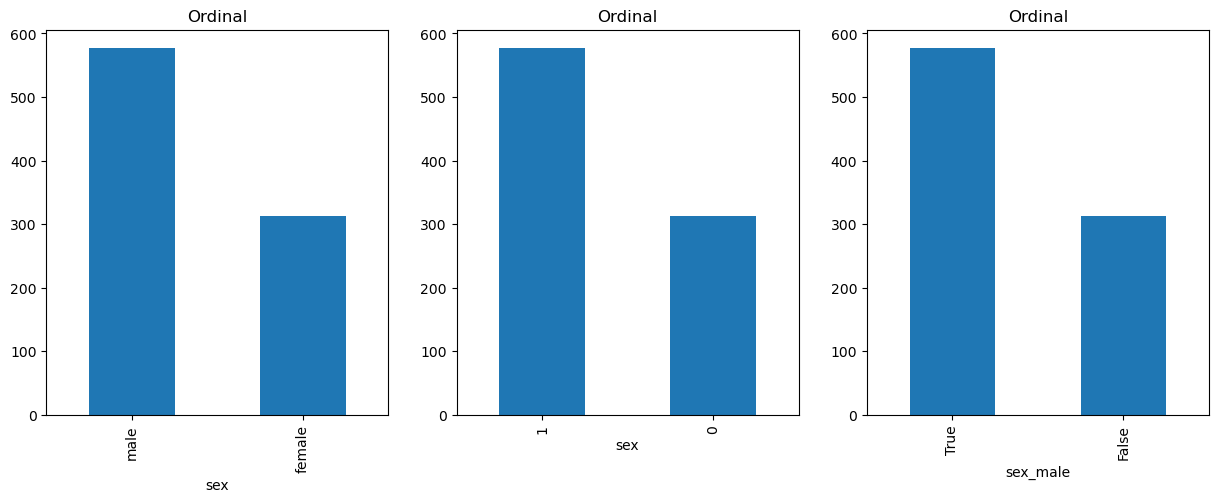

In [39]:
fig, axes = plt.subplots(1,3, figsize=(15,5))
df["sex"].value_counts().plot(kind="bar", ax=axes[0], title= "Ordinal")
df_label["sex"].value_counts().plot(kind="bar", ax=axes[1], title= "Ordinal")
df_onehot["sex_male"].value_counts().plot(kind="bar", ax=axes[2], title= "Ordinal")